# A2 — Unified Evaluation and Robustness Analysis

**Member A contribution: dataset/evaluation integration and robustness analysis**

This notebook integrates the outputs produced by the three model owners:

- **Traditional:** SIFT + Bag-of-Visual-Words + SVM
- **Scratch:** ResNet18 trained from random initialisation
- **Pretrained:** ImageNet-pretrained ResNet18 with fine-tuning

The notebook does not train the models again. It performs the following integration work:

1. Checks that all clean and robustness result files are present and correctly formatted.
2. Rebuilds one unified robustness summary from the detailed metrics JSON files.
3. Verifies that all three models contain one clean baseline and 15 degraded conditions.
4. Compares clean Top-1, Top-5 and Macro-F1 performance.
5. Visualises all degradation types and severity levels.
6. Measures absolute performance drop and clean-performance retention.
7. Produces robustness curves, heatmaps and ranking tables.
8. Uses per-image predictions for representative failure and per-class sensitivity analysis.
9. Generates report-ready tables, figures and key findings.

### Experimental protocol

All models use the same fixed 5,000-image test split. Five degradation types are evaluated at three severity levels:

- Gaussian noise: 0.05, 0.10, 0.20
- Gaussian blur: 3, 5, 7
- Brightness factor: 0.8, 0.6, 0.4
- Contrast factor: 0.8, 0.6, 0.4
- JPEG quality: 70, 40, 20

Gaussian noise was generated independently for each test image at the specified standard deviation. The models use the same fixed test split and the same severity levels; this notebook does not claim that the random corrupted pixels were identical across separately executed model runs.

## 1. Setup

The notebook automatically finds the repository root whether it is opened from the project root or from `notebooks/`.

The GitHub repository does not contain the raw dataset. For image visualisation, the path resolver also checks the sibling local folder `COMP9517_Project`. All metric, prediction and summary analyses can still run without raw images.

In [1]:
from pathlib import Path
import os
import sys
import json
import subprocess
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageOps
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'src').exists():
    raise FileNotFoundError(
        'Could not find the project root. Open this notebook from the repository root or notebooks/.'
    )

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / 'results'
CLEAN_DIR = RESULTS_DIR / 'clean'
ROBUSTNESS_DIR = RESULTS_DIR / 'robustness'
ROBUSTNESS_METRICS_DIR = ROBUSTNESS_DIR / 'metrics'
ROBUSTNESS_PREDICTIONS_DIR = ROBUSTNESS_DIR / 'predictions'
FIGURE_DIR = RESULTS_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ['traditional', 'scratch', 'pretrained']
MODEL_LABELS = {
    'traditional': 'Traditional',
    'scratch': 'Scratch ResNet18',
    'pretrained': 'Pretrained ResNet18',
}

IMAGE_ROOT_CANDIDATES = [
    PROJECT_ROOT,
    PROJECT_ROOT.parent / 'COMP9517_Project',
]

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print('Project root:', PROJECT_ROOT)
print('Python:', sys.executable)
print('Figure output:', FIGURE_DIR)
print('Image root candidates:')
for candidate in IMAGE_ROOT_CANDIDATES:
    print(' -', candidate, '| exists:', candidate.exists())

Project root: D:\Code\unsw\comp9517\COMP9517-project-github
Python: c:\Users\leo\anaconda3\envs\comp9517\python.exe
Figure output: D:\Code\unsw\comp9517\COMP9517-project-github\results\figures
Image root candidates:
 - D:\Code\unsw\comp9517\COMP9517-project-github | exists: True
 - D:\Code\unsw\comp9517\COMP9517_Project | exists: True


## 2. Check all input files

For every model, the expected inputs are one clean prediction CSV, one clean metrics JSON, 15 degraded prediction CSV files and 15 degraded metrics JSON files.

In [2]:
def fast_csv_row_count(path: Path) -> int:
    # Count data rows without loading the whole CSV into memory.
    with path.open('r', encoding='utf-8', errors='replace') as f:
        return max(sum(1 for _ in f) - 1, 0)

required_prediction_columns = {'image_path', 'true_idx', 'pred_idx', 'top5_idx'}
input_rows = []

for model in MODELS:
    clean_pred = CLEAN_DIR / f'{model}_predictions.csv'
    clean_metrics = CLEAN_DIR / f'{model}_metrics.json'
    robustness_preds = sorted(ROBUSTNESS_PREDICTIONS_DIR.glob(f'{model}_*_predictions.csv'))
    robustness_metrics = sorted(ROBUSTNESS_METRICS_DIR.glob(f'{model}_*_metrics.json'))
    clean_rows = fast_csv_row_count(clean_pred) if clean_pred.exists() else 0
    degraded_row_counts = [fast_csv_row_count(path) for path in robustness_preds]

    input_rows.append({
        'model': MODEL_LABELS[model],
        'clean_prediction': clean_pred.exists(),
        'clean_metrics': clean_metrics.exists(),
        'clean_prediction_rows': clean_rows,
        'robustness_prediction_files': len(robustness_preds),
        'robustness_metrics_files': len(robustness_metrics),
        'min_degraded_rows': min(degraded_row_counts) if degraded_row_counts else 0,
        'max_degraded_rows': max(degraded_row_counts) if degraded_row_counts else 0,
    })

input_completeness = pd.DataFrame(input_rows)
display(input_completeness)

assert input_completeness['clean_prediction'].all()
assert input_completeness['clean_metrics'].all()
assert (input_completeness['clean_prediction_rows'] == 5000).all()
assert (input_completeness['robustness_prediction_files'] == 15).all()
assert (input_completeness['robustness_metrics_files'] == 15).all()
assert (input_completeness['min_degraded_rows'] == 5000).all()
assert (input_completeness['max_degraded_rows'] == 5000).all()

print('Input completeness check passed.')

,model,clean_prediction,clean_metrics,clean_prediction_rows,robustness_prediction_files,robustness_metrics_files,min_degraded_rows,max_degraded_rows
0,Traditional,True,True,5000,15,15,5000,5000
1,Scratch ResNet18,True,True,5000,15,15,5000,5000
2,Pretrained ResNet18,True,True,5000,15,15,5000,5000


Input completeness check passed.


### 2.1 Validate clean prediction format and shared test split

This confirms that all three models use the same 5,000 image paths and true labels, and that every Top-5 field contains five class indices.

In [3]:
def normalise_image_path(value: str) -> str:
    return str(value).replace('\\', '/').lower()

clean_predictions = {}

for model in MODELS:
    path = CLEAN_DIR / f'{model}_predictions.csv'
    df = pd.read_csv(path)
    missing_columns = required_prediction_columns - set(df.columns)
    assert not missing_columns, f'{model} is missing columns: {missing_columns}'
    assert len(df) == 5000

    df['path_key'] = df['image_path'].map(normalise_image_path)
    df['top5_length'] = df['top5_idx'].astype(str).str.split().map(len)
    assert (df['top5_length'] == 5).all()
    assert df['path_key'].is_unique
    clean_predictions[model] = df

reference = (
    clean_predictions['traditional'][['path_key', 'true_idx']]
    .sort_values('path_key')
    .reset_index(drop=True)
)

alignment_rows = []
for model in MODELS:
    current = (
        clean_predictions[model][['path_key', 'true_idx']]
        .sort_values('path_key')
        .reset_index(drop=True)
    )
    alignment_rows.append({
        'model': MODEL_LABELS[model],
        'same_5000_image_paths': current['path_key'].equals(reference['path_key']),
        'same_true_labels': current['true_idx'].equals(reference['true_idx']),
        'class_idx_min': int(current['true_idx'].min()),
        'class_idx_max': int(current['true_idx'].max()),
    })

alignment_table = pd.DataFrame(alignment_rows)
display(alignment_table)

assert alignment_table['same_5000_image_paths'].all()
assert alignment_table['same_true_labels'].all()
assert (alignment_table['class_idx_min'] == 0).all()
assert (alignment_table['class_idx_max'] == 499).all()

print('All three models use the same fixed test images and labels.')

,model,same_5000_image_paths,same_true_labels,class_idx_min,class_idx_max
0,Traditional,True,True,0,499
1,Scratch ResNet18,True,True,0,499
2,Pretrained ResNet18,True,True,0,499


All three models use the same fixed test images and labels.


## 3. Rebuild the unified robustness summary

Member A rebuilds the combined table directly from the 3 clean metrics files and 45 degraded metrics files.

In [4]:
combined_csv = ROBUSTNESS_DIR / 'combined_robustness_results.csv'

summary_command = [
    sys.executable,
    str(PROJECT_ROOT / 'src' / 'summarize_robustness.py'),
    '--clean-dir', str(CLEAN_DIR),
    '--metrics-dir', str(ROBUSTNESS_METRICS_DIR),
    '--out-csv', str(combined_csv),
]

print('Running:')
print(' '.join(summary_command))

result = subprocess.run(
    summary_command,
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.stderr:
    print(result.stderr)

assert result.returncode == 0
assert combined_csv.exists()

Running:
c:\Users\leo\anaconda3\envs\comp9517\python.exe D:\Code\unsw\comp9517\COMP9517-project-github\src\summarize_robustness.py --clean-dir D:\Code\unsw\comp9517\COMP9517-project-github\results\clean --metrics-dir D:\Code\unsw\comp9517\COMP9517-project-github\results\robustness\metrics --out-csv D:\Code\unsw\comp9517\COMP9517-project-github\results\robustness\combined_robustness_results.csv
Saved summary to: D:\Code\unsw\comp9517\COMP9517-project-github\results\robustness\combined_robustness_results.csv
      model degradation severity  top1_accuracy  macro_f1
traditional       clean        0         0.1074  0.098175
traditional       noise     0.05         0.0946  0.086117
traditional       noise      0.1         0.0796  0.068765
traditional       noise      0.2         0.0392  0.031154
traditional        blur        3         0.0542  0.049134
traditional        blur        5         0.0212  0.016658
traditional        blur        7         0.0090  0.004252
traditional  brightness 

### 3.1 Validate the 48 experimental conditions

The required structure is 3 models × (1 clean + 15 degraded) = 48 rows.

In [5]:
robustness_df = pd.read_csv(combined_csv)
robustness_df['severity_numeric'] = pd.to_numeric(robustness_df['severity'], errors='coerce')

model_condition_counts = robustness_df.groupby('model').size().rename('number_of_conditions').reset_index()
condition_breakdown = robustness_df.groupby(['model', 'degradation']).size().rename('number_of_levels').reset_index()

print('Combined shape:', robustness_df.shape)
display(model_condition_counts)
display(condition_breakdown)

assert len(robustness_df) == 48
assert set(robustness_df['model']) == set(MODELS)
assert (robustness_df.groupby('model').size() == 16).all()

expected_counts = {'clean': 1, 'noise': 3, 'blur': 3, 'brightness': 3, 'contrast': 3, 'jpeg': 3}
for model in MODELS:
    counts = robustness_df[robustness_df['model'] == model]['degradation'].value_counts().to_dict()
    assert counts == expected_counts, f'Unexpected condition count for {model}: {counts}'

print('All three models contain one clean baseline and 15 degraded conditions.')

Combined shape: (48, 10)


,model,number_of_conditions
0,pretrained,16
1,scratch,16
2,traditional,16


,model,degradation,number_of_levels
0,pretrained,blur,3
1,pretrained,brightness,3
2,pretrained,clean,1
3,pretrained,contrast,3
4,pretrained,jpeg,3
5,pretrained,noise,3
6,scratch,blur,3
7,scratch,brightness,3
8,scratch,clean,1
9,scratch,contrast,3


All three models contain one clean baseline and 15 degraded conditions.


## 4. Clean performance comparison

The main metrics are Top-1 accuracy, Top-5 accuracy and Macro-F1.

,Model,Top-1 (%),Top-5 (%),Macro-F1 (%)
0,Traditional,10.7400,23.0400,9.8200
1,Scratch ResNet18,32.1000,57.6600,29.7300
2,Pretrained ResNet18,68.2400,86.9800,67.9500


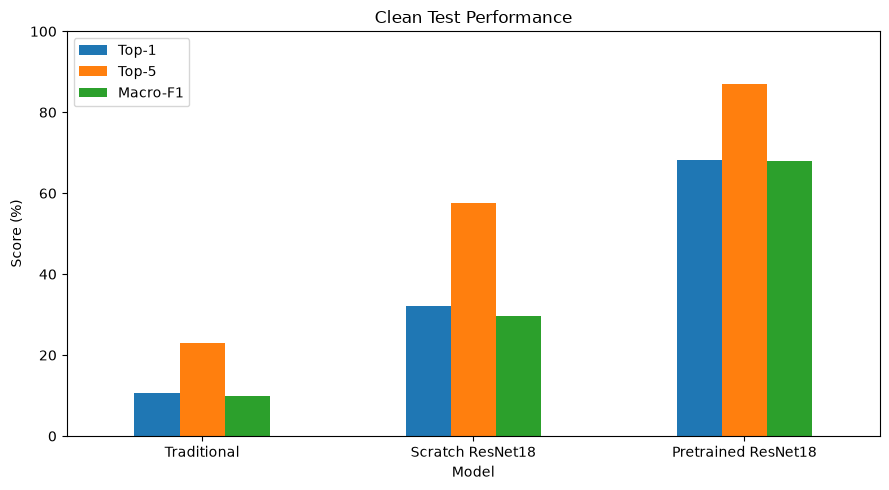

Best clean Top-1 model: Pretrained ResNet18 (68.24%).


In [6]:
clean_rows = []
for model in MODELS:
    metrics_path = CLEAN_DIR / f'{model}_metrics.json'
    with metrics_path.open('r', encoding='utf-8') as f:
        metrics = json.load(f)
    clean_rows.append({
        'model': model,
        'model_label': MODEL_LABELS[model],
        'top1_accuracy': float(metrics['top1_accuracy']),
        'top5_accuracy': float(metrics['top5_accuracy']),
        'macro_precision': float(metrics['macro_precision']),
        'macro_recall': float(metrics['macro_recall']),
        'macro_f1': float(metrics['macro_f1']),
    })

clean_summary = pd.DataFrame(clean_rows)
clean_summary.to_csv(CLEAN_DIR / 'clean_model_comparison.csv', index=False)

clean_display = clean_summary.copy()
for column in ['top1_accuracy', 'top5_accuracy', 'macro_precision', 'macro_recall', 'macro_f1']:
    clean_display[column] *= 100

display(
    clean_display[['model_label', 'top1_accuracy', 'top5_accuracy', 'macro_f1']]
    .rename(columns={
        'model_label': 'Model',
        'top1_accuracy': 'Top-1 (%)',
        'top5_accuracy': 'Top-5 (%)',
        'macro_f1': 'Macro-F1 (%)',
    })
    .round(2)
)

plot_df = (
    clean_display.set_index('model_label')[['top1_accuracy', 'top5_accuracy', 'macro_f1']]
    .rename(columns={'top1_accuracy': 'Top-1', 'top5_accuracy': 'Top-5', 'macro_f1': 'Macro-F1'})
)

ax = plot_df.plot(kind='bar', figsize=(9, 5))
ax.set_title('Clean Test Performance')
ax.set_xlabel('Model')
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'A2_clean_model_comparison.png', dpi=200)
plt.show()

best_clean = clean_summary.loc[clean_summary['top1_accuracy'].idxmax()]
print(f"Best clean Top-1 model: {best_clean['model_label']} ({best_clean['top1_accuracy'] * 100:.2f}%).")

## 5. Robustness protocol and visual examples

Degradation is applied during evaluation rather than by creating a permanent second dataset.

In [7]:
from src.degradations import DEGRADATION_LEVELS, apply_degradation, gaussian_noise

protocol_table = pd.DataFrame([
    ['Gaussian noise', '0.05, 0.10, 0.20', 'Higher sigma', 3],
    ['Gaussian blur', '3, 5, 7', 'Larger kernel', 3],
    ['Brightness', '0.8, 0.6, 0.4', 'Lower factor', 3],
    ['Contrast', '0.8, 0.6, 0.4', 'Lower factor', 3],
    ['JPEG compression', '70, 40, 20', 'Lower quality', 3],
], columns=['degradation', 'severity_levels', 'stronger_degradation_direction', 'conditions_per_model'])

display(protocol_table)
print('Test images per condition: 5,000')
print('Conditions per model including clean: 16')
print('Approximate test predictions across three models:', 3 * 16 * 5000)

,degradation,severity_levels,stronger_degradation_direction,conditions_per_model
0,Gaussian noise,"0.05, 0.10, 0.20",Higher sigma,3
1,Gaussian blur,"3, 5, 7",Larger kernel,3
2,Brightness,"0.8, 0.6, 0.4",Lower factor,3
3,Contrast,"0.8, 0.6, 0.4",Lower factor,3
4,JPEG compression,"70, 40, 20",Lower quality,3


Test images per condition: 5,000
Conditions per model including clean: 16
Approximate test predictions across three models: 240000


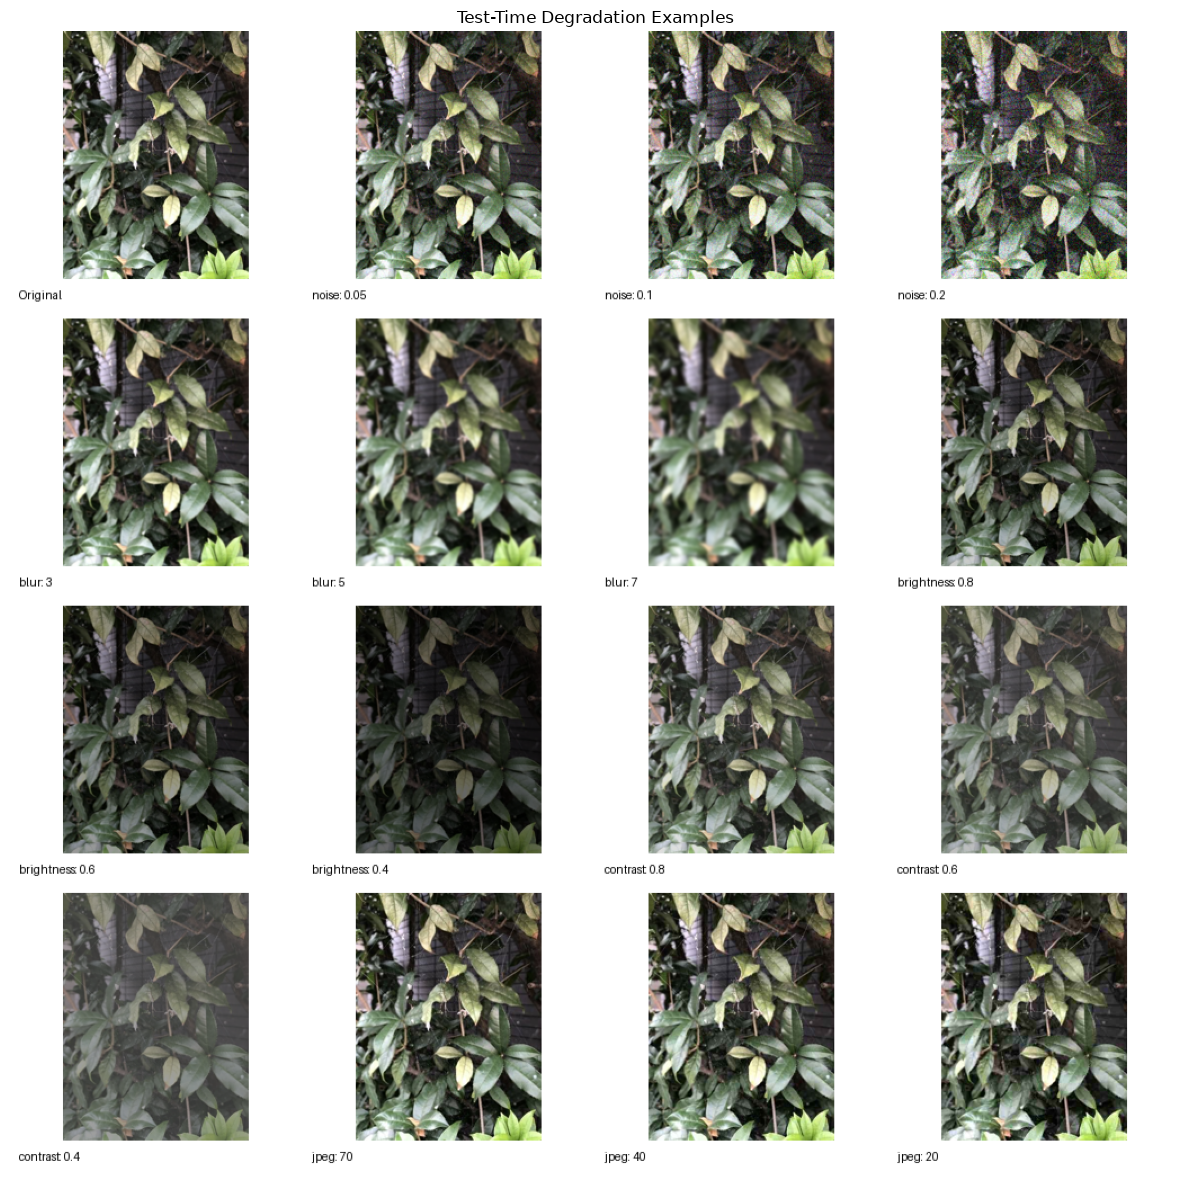

In [8]:
def resolve_image_path(path_value: str):
    path = Path(str(path_value))
    if path.is_absolute() and path.exists():
        return path
    normalised = Path(str(path_value).replace('\\', '/'))
    for root in IMAGE_ROOT_CANDIDATES:
        candidate = root / normalised
        if candidate.exists():
            return candidate
    return None


def make_labeled_tile(image, label, tile_size=(260, 220), text_height=35):
    image = image.convert('RGB')
    canvas = Image.new('RGB', (tile_size[0], tile_size[1] + text_height), 'white')
    fitted = ImageOps.contain(image, tile_size)
    x = (tile_size[0] - fitted.width) // 2
    y = (tile_size[1] - fitted.height) // 2
    canvas.paste(fitted, (x, y))
    draw = ImageDraw.Draw(canvas)
    draw.text((8, tile_size[1] + 8), label, fill='black')
    return canvas


test_split_df = pd.read_csv(PROJECT_ROOT / 'data' / 'splits' / 'test_paths.csv')
example_path = resolve_image_path(test_split_df.iloc[0]['image_path'])

if example_path is None:
    print('Raw image not found. Metric analysis can continue; image visualisation is skipped.')
else:
    original = Image.open(example_path).convert('RGB')
    tiles = [make_labeled_tile(original, 'Original')]

    for degradation, severities in DEGRADATION_LEVELS.items():
        for severity in severities:
            if degradation == 'noise':
                degraded = gaussian_noise(original, sigma=float(severity), seed=9517)
            else:
                degraded = apply_degradation(original, degradation, severity)
            tiles.append(make_labeled_tile(degraded, f'{degradation}: {severity}'))

    columns = 4
    rows = int(np.ceil(len(tiles) / columns))
    tile_w, tile_h = tiles[0].size
    contact_sheet = Image.new('RGB', (columns * tile_w, rows * tile_h), 'white')

    for index, tile in enumerate(tiles):
        x = (index % columns) * tile_w
        y = (index // columns) * tile_h
        contact_sheet.paste(tile, (x, y))

    contact_sheet.save(FIGURE_DIR / 'A2_degradation_examples.png')
    plt.figure(figsize=(14, 12))
    plt.imshow(contact_sheet)
    plt.axis('off')
    plt.title('Test-Time Degradation Examples')
    plt.tight_layout()
    plt.show()

## 6. Calculate performance drop and retention

Absolute drop is `clean score − degraded score`. Retention is `degraded score / clean score × 100`.

In [9]:
clean_baselines = (
    robustness_df[robustness_df['degradation'] == 'clean'][['model', 'top1_accuracy', 'macro_f1']]
    .rename(columns={'top1_accuracy': 'clean_top1_accuracy', 'macro_f1': 'clean_macro_f1'})
)

degraded_df = robustness_df[robustness_df['degradation'] != 'clean'].merge(clean_baselines, on='model', how='left').copy()
degraded_df['top1_absolute_drop'] = degraded_df['clean_top1_accuracy'] - degraded_df['top1_accuracy']
degraded_df['macro_f1_absolute_drop'] = degraded_df['clean_macro_f1'] - degraded_df['macro_f1']
degraded_df['top1_relative_drop_pct'] = degraded_df['top1_absolute_drop'] / degraded_df['clean_top1_accuracy'] * 100
degraded_df['macro_f1_relative_drop_pct'] = degraded_df['macro_f1_absolute_drop'] / degraded_df['clean_macro_f1'] * 100
degraded_df['top1_retention_pct'] = degraded_df['top1_accuracy'] / degraded_df['clean_top1_accuracy'] * 100
degraded_df['macro_f1_retention_pct'] = degraded_df['macro_f1'] / degraded_df['clean_macro_f1'] * 100

drop_output = ROBUSTNESS_DIR / 'robustness_with_drop.csv'
degraded_df.to_csv(drop_output, index=False)

drop_display = degraded_df[['model', 'degradation', 'severity', 'top1_accuracy', 'top1_absolute_drop', 'top1_retention_pct', 'macro_f1', 'macro_f1_absolute_drop', 'macro_f1_retention_pct']].copy()
for column in ['top1_accuracy', 'top1_absolute_drop', 'macro_f1', 'macro_f1_absolute_drop']:
    drop_display[column] *= 100

display(drop_display.head(15).round(2))
print('Saved:', drop_output)

,model,degradation,severity,top1_accuracy,top1_absolute_drop,top1_retention_pct,macro_f1,macro_f1_absolute_drop,macro_f1_retention_pct
0,traditional,noise,0.0500,9.4600,1.2800,88.0800,8.6100,1.2100,87.7200
1,traditional,noise,0.1000,7.9600,2.7800,74.1200,6.8800,2.9400,70.0400
2,traditional,noise,0.2000,3.9200,6.8200,36.5000,3.1200,6.7000,31.7300
3,traditional,blur,3.0000,5.4200,5.3200,50.4700,4.9100,4.9000,50.0500
4,traditional,blur,5.0000,2.1200,8.6200,19.7400,1.6700,8.1500,16.9700
5,traditional,blur,7.0000,0.9000,9.8400,8.3800,0.4300,9.3900,4.3300
6,traditional,brightness,0.4000,4.1200,6.6200,38.3600,4.0500,5.7700,41.2200
7,traditional,brightness,0.6000,8.7000,2.0400,81.0100,8.2200,1.6000,83.7500
8,traditional,brightness,0.8000,10.0600,0.6800,93.6700,9.2000,0.6100,93.7600
9,traditional,contrast,0.4000,4.2800,6.4600,39.8500,4.2100,5.6000,42.9100


Saved: D:\Code\unsw\comp9517\COMP9517-project-github\results\robustness\robustness_with_drop.csv


## 7. Robustness curves

Each curve includes the clean baseline followed by three severity levels in mild-to-strong order.

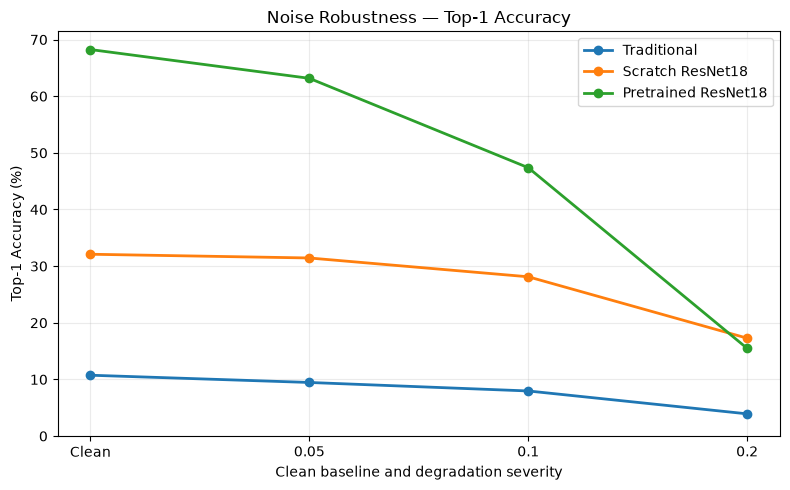

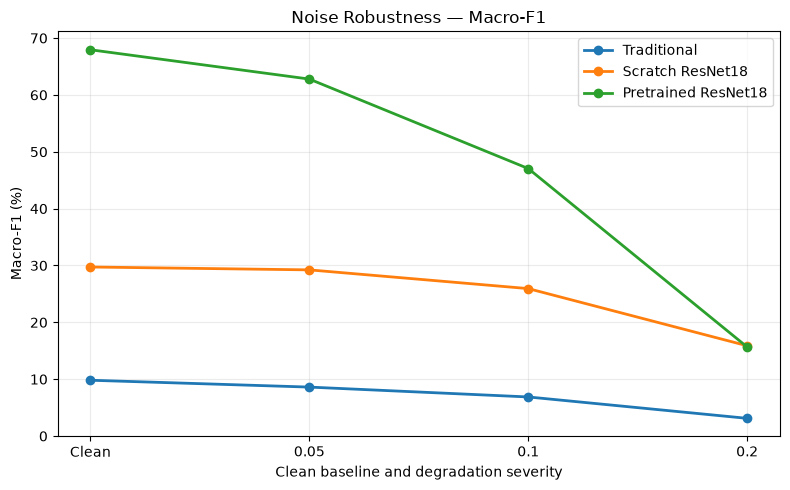

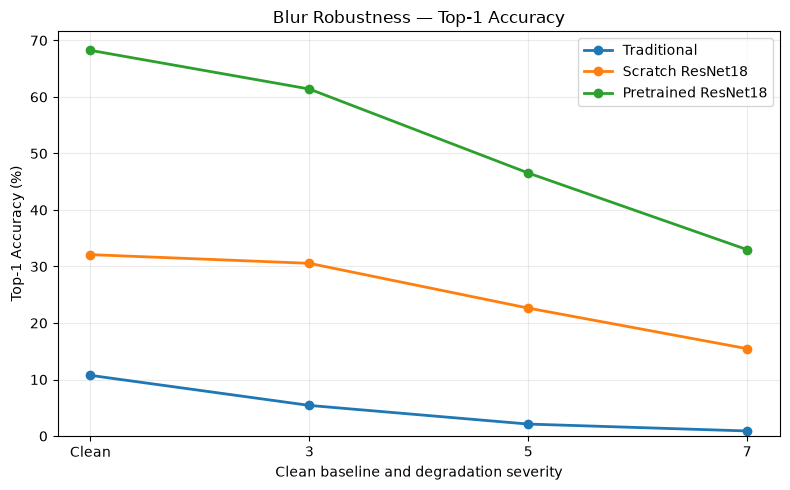

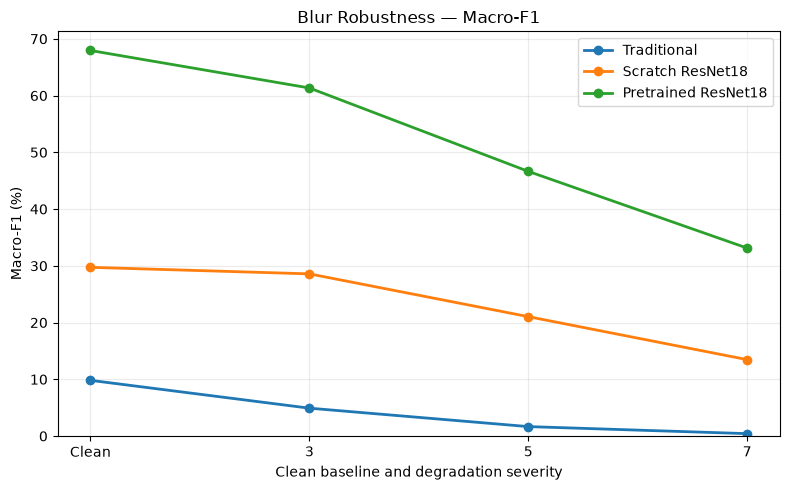

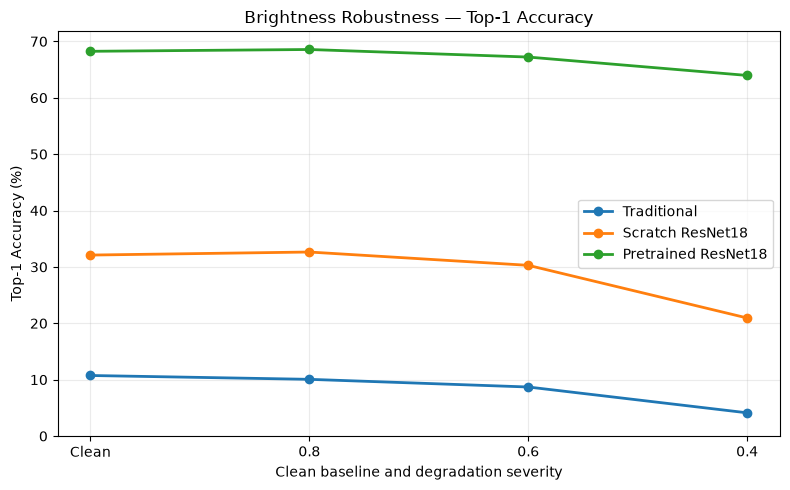

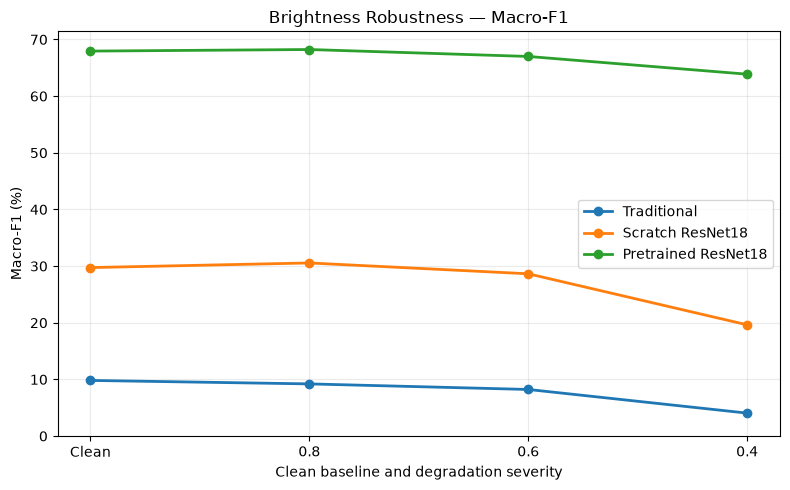

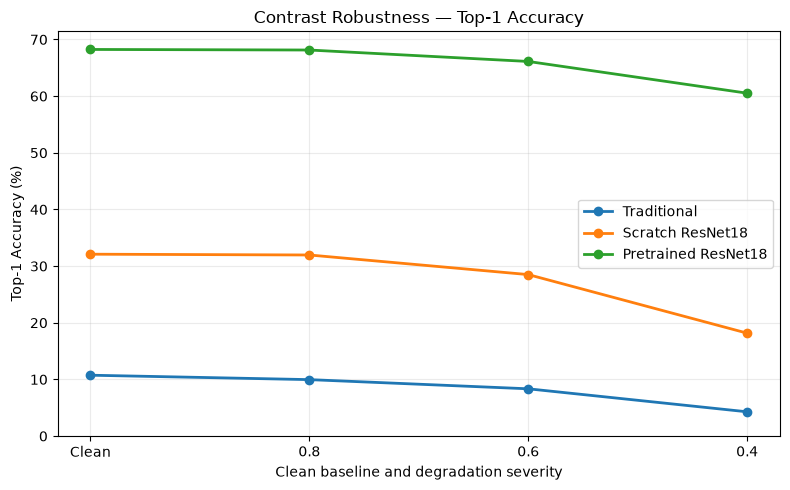

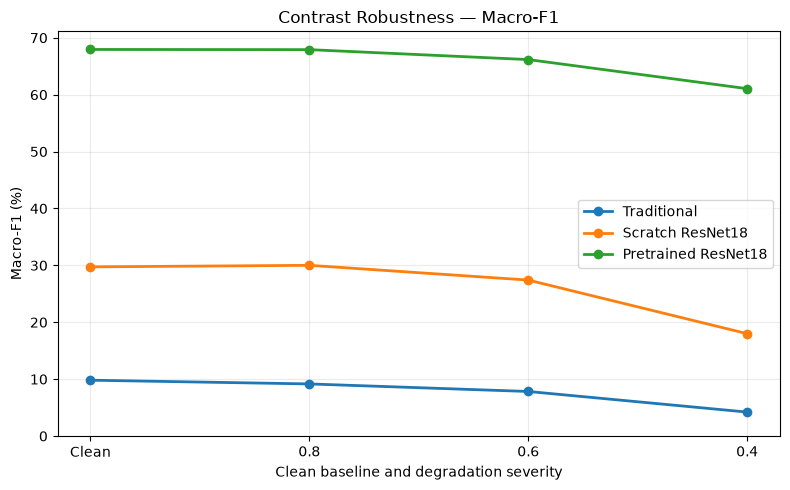

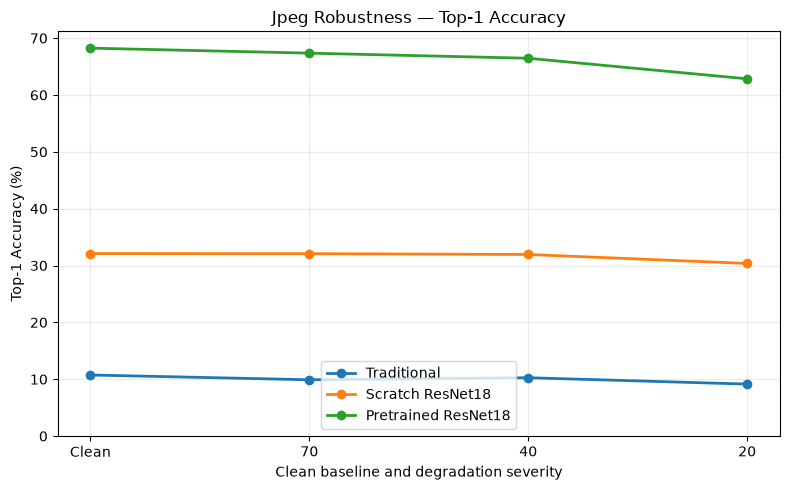

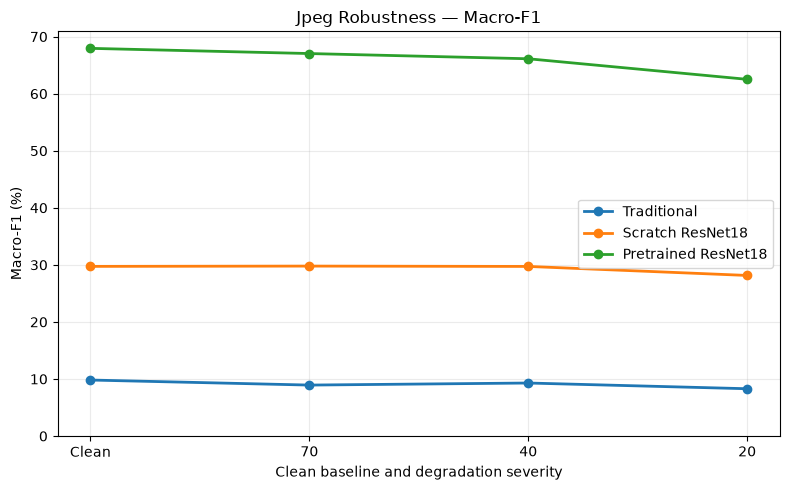

In [10]:
SEVERITY_ORDER = {
    'noise': [0.05, 0.10, 0.20],
    'blur': [3, 5, 7],
    'brightness': [0.8, 0.6, 0.4],
    'contrast': [0.8, 0.6, 0.4],
    'jpeg': [70, 40, 20],
}


def plot_robustness_curve(summary_df, degradation, metric, output_path):
    plt.figure(figsize=(8, 5))
    severity_values = SEVERITY_ORDER[degradation]
    x_labels = ['Clean'] + [str(value) for value in severity_values]
    x_positions = list(range(len(x_labels)))

    for model in MODELS:
        clean_value = float(summary_df[(summary_df['model'] == model) & (summary_df['degradation'] == 'clean')][metric].iloc[0])
        condition_df = summary_df[(summary_df['model'] == model) & (summary_df['degradation'] == degradation)].copy()
        severity_map = {float(row['severity_numeric']): float(row[metric]) for _, row in condition_df.iterrows()}
        values = [clean_value] + [severity_map[float(severity)] for severity in severity_values]
        plt.plot(x_positions, np.array(values) * 100, marker='o', linewidth=2, label=MODEL_LABELS[model])

    metric_label = 'Top-1 Accuracy' if metric == 'top1_accuracy' else 'Macro-F1'
    plt.title(f'{degradation.title()} Robustness — {metric_label}')
    plt.xlabel('Clean baseline and degradation severity')
    plt.ylabel(f'{metric_label} (%)')
    plt.xticks(x_positions, x_labels)
    plt.ylim(bottom=0)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()

for degradation in SEVERITY_ORDER:
    plot_robustness_curve(robustness_df, degradation, 'top1_accuracy', FIGURE_DIR / f'A2_{degradation}_top1_accuracy.png')
    plot_robustness_curve(robustness_df, degradation, 'macro_f1', FIGURE_DIR / f'A2_{degradation}_macro_f1.png')

## 8. Strongest-severity comparison

This compares noise 0.20, blur 7, brightness 0.4, contrast 0.4 and JPEG quality 20.

,model,degradation,severity,top1_accuracy,top1_absolute_drop,top1_retention_pct,macro_f1,macro_f1_absolute_drop,macro_f1_retention_pct
5,pretrained,blur,7.0000,32.9800,35.2600,48.3300,33.1200,34.8200,48.7500
4,scratch,blur,7.0000,15.4600,16.6400,48.1600,13.4700,16.2700,45.2900
3,traditional,blur,7.0000,0.9000,9.8400,8.3800,0.4300,9.3900,4.3300
8,pretrained,brightness,0.4000,63.9600,4.2800,93.7300,63.8700,4.0800,94.0000
7,scratch,brightness,0.4000,20.9400,11.1600,65.2300,19.6300,10.1100,66.0100
6,traditional,brightness,0.4000,4.1200,6.6200,38.3600,4.0500,5.7700,41.2200
11,pretrained,contrast,0.4000,60.5200,7.7200,88.6900,61.0600,6.8900,89.8600
10,scratch,contrast,0.4000,18.1600,13.9400,56.5700,17.9900,11.7400,60.5200
9,traditional,contrast,0.4000,4.2800,6.4600,39.8500,4.2100,5.6000,42.9100
14,pretrained,jpeg,20.0000,62.8400,5.4000,92.0900,62.5200,5.4300,92.0100


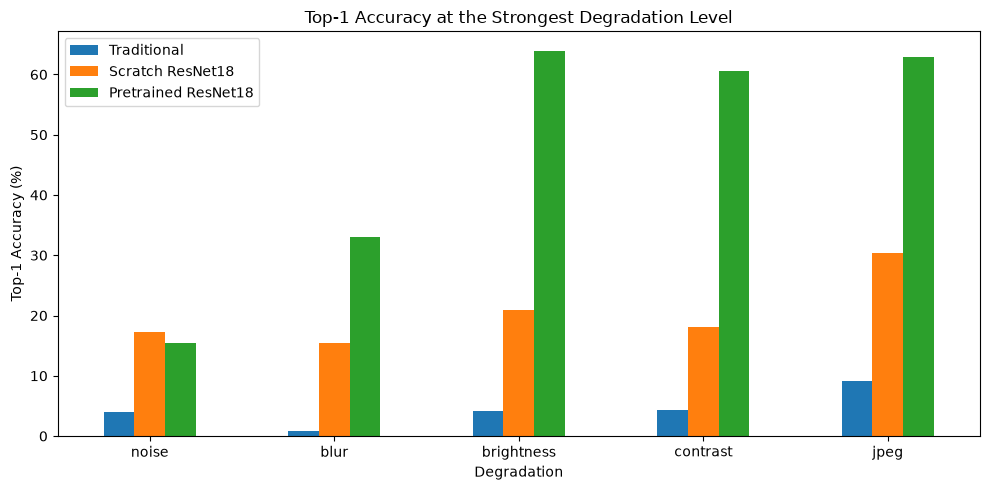

In [11]:
STRONGEST_SEVERITY = {'noise': 0.20, 'blur': 7, 'brightness': 0.4, 'contrast': 0.4, 'jpeg': 20}
strongest_rows = []

for degradation, severity in STRONGEST_SEVERITY.items():
    condition = degraded_df[(degraded_df['degradation'] == degradation) & np.isclose(degraded_df['severity_numeric'], float(severity))].copy()
    strongest_rows.append(condition)

strongest_df = pd.concat(strongest_rows, ignore_index=True)
strongest_df.to_csv(ROBUSTNESS_DIR / 'strongest_severity_comparison.csv', index=False)

strongest_display = strongest_df[['model', 'degradation', 'severity', 'top1_accuracy', 'top1_absolute_drop', 'top1_retention_pct', 'macro_f1', 'macro_f1_absolute_drop', 'macro_f1_retention_pct']].copy()
for column in ['top1_accuracy', 'top1_absolute_drop', 'macro_f1', 'macro_f1_absolute_drop']:
    strongest_display[column] *= 100

display(strongest_display.sort_values(['degradation', 'top1_accuracy'], ascending=[True, False]).round(2))

strongest_top1_pivot = strongest_df.pivot(index='degradation', columns='model', values='top1_accuracy').reindex(list(STRONGEST_SEVERITY.keys()))[MODELS] * 100
strongest_top1_pivot.columns = [MODEL_LABELS[c] for c in strongest_top1_pivot.columns]

ax = strongest_top1_pivot.plot(kind='bar', figsize=(10, 5))
ax.set_title('Top-1 Accuracy at the Strongest Degradation Level')
ax.set_xlabel('Degradation')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'A2_strongest_severity_top1.png', dpi=200)
plt.show()

## 9. Robustness heatmaps

The first heatmap uses mean Top-1 drop across all three severities. The second uses the strongest severity only.

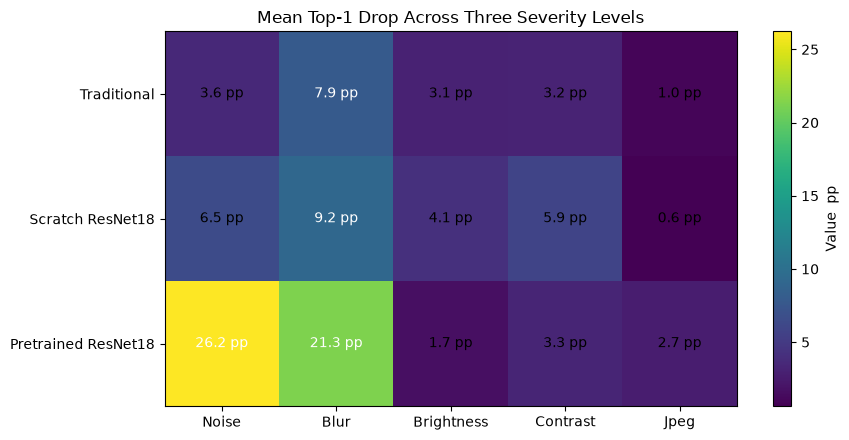

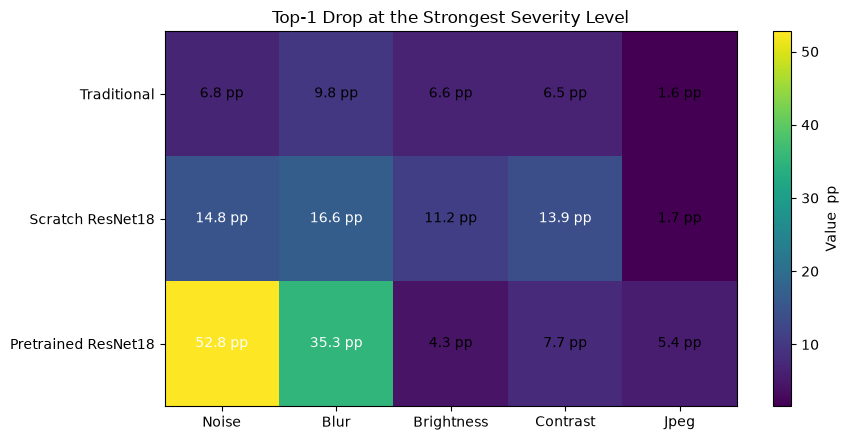

In [12]:
def draw_annotated_heatmap(matrix, title, output_path, value_suffix=''):
    values = matrix.to_numpy(dtype=float)
    plt.figure(figsize=(9, 4.5))
    image = plt.imshow(values, aspect='auto')
    plt.colorbar(image, label=f'Value {value_suffix}'.strip())
    plt.xticks(range(len(matrix.columns)), [str(column).title() for column in matrix.columns])
    plt.yticks(range(len(matrix.index)), [MODEL_LABELS.get(index, str(index)) for index in matrix.index])
    plt.title(title)

    threshold = np.nanmean(values)
    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):
            value = values[row_index, column_index]
            text_color = 'white' if value > threshold else 'black'
            plt.text(column_index, row_index, f'{value:.1f}{value_suffix}', ha='center', va='center', color=text_color)

    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()

mean_drop_matrix = degraded_df.groupby(['model', 'degradation'])['top1_absolute_drop'].mean().unstack('degradation').reindex(index=MODELS, columns=list(SEVERITY_ORDER.keys())) * 100
strongest_drop_matrix = strongest_df.pivot(index='model', columns='degradation', values='top1_absolute_drop').reindex(index=MODELS, columns=list(SEVERITY_ORDER.keys())) * 100

draw_annotated_heatmap(mean_drop_matrix, 'Mean Top-1 Drop Across Three Severity Levels', FIGURE_DIR / 'A2_mean_top1_drop_heatmap.png', ' pp')
draw_annotated_heatmap(strongest_drop_matrix, 'Top-1 Drop at the Strongest Severity Level', FIGURE_DIR / 'A2_strongest_top1_drop_heatmap.png', ' pp')

## 10. Model-level robustness ranking

This summarises average degraded performance, average drop, average retention and each model's worst condition.

In [13]:
model_summary_rows = []

for model in MODELS:
    model_df = degraded_df[degraded_df['model'] == model].copy()
    worst_row = model_df.loc[model_df['top1_absolute_drop'].idxmax()]
    best_retention_row = model_df.loc[model_df['top1_retention_pct'].idxmax()]

    model_summary_rows.append({
        'model': model,
        'model_label': MODEL_LABELS[model],
        'clean_top1': float(model_df['clean_top1_accuracy'].iloc[0]),
        'mean_degraded_top1': float(model_df['top1_accuracy'].mean()),
        'mean_top1_drop': float(model_df['top1_absolute_drop'].mean()),
        'mean_top1_retention_pct': float(model_df['top1_retention_pct'].mean()),
        'mean_macro_f1_drop': float(model_df['macro_f1_absolute_drop'].mean()),
        'worst_condition': f"{worst_row['degradation']} {worst_row['severity']}",
        'worst_condition_top1': float(worst_row['top1_accuracy']),
        'best_retention_condition': f"{best_retention_row['degradation']} {best_retention_row['severity']}",
    })

model_robustness_summary = pd.DataFrame(model_summary_rows)
model_robustness_summary.to_csv(ROBUSTNESS_DIR / 'robustness_model_summary.csv', index=False)

summary_display = model_robustness_summary.copy()
for column in ['clean_top1', 'mean_degraded_top1', 'mean_top1_drop', 'mean_macro_f1_drop']:
    summary_display[column] *= 100

display(
    summary_display[['model_label', 'clean_top1', 'mean_degraded_top1', 'mean_top1_drop', 'mean_top1_retention_pct', 'mean_macro_f1_drop', 'worst_condition']]
    .rename(columns={
        'model_label': 'Model',
        'clean_top1': 'Clean Top-1 (%)',
        'mean_degraded_top1': 'Mean Degraded Top-1 (%)',
        'mean_top1_drop': 'Mean Top-1 Drop (pp)',
        'mean_top1_retention_pct': 'Mean Retention (%)',
        'mean_macro_f1_drop': 'Mean Macro-F1 Drop (pp)',
        'worst_condition': 'Worst Condition',
    })
    .round(2)
)

,Model,Clean Top-1 (%),Mean Degraded Top-1 (%),Mean Top-1 Drop (pp),Mean Retention (%),Mean Macro-F1 Drop (pp),Worst Condition
0,Traditional,10.7400,6.9700,3.7700,64.8900,3.5000,blur 7.0
1,Scratch ResNet18,32.1000,26.8200,5.2800,83.5600,4.6700,blur 7.0
2,Pretrained ResNet18,68.2400,57.2100,11.0300,83.8300,10.8400,noise 0.2


### 10.1 Best model by degradation

The best absolute score and the best retention are reported separately because the clean baselines differ substantially.

In [14]:
degradation_ranking_rows = []

for degradation in SEVERITY_ORDER:
    severe = strongest_df[strongest_df['degradation'] == degradation].copy()
    absolute_winner = severe.loc[severe['top1_accuracy'].idxmax()]
    retention_winner = severe.loc[severe['top1_retention_pct'].idxmax()]

    degradation_ranking_rows.append({
        'degradation': degradation,
        'strongest_severity': STRONGEST_SEVERITY[degradation],
        'best_absolute_model': MODEL_LABELS[absolute_winner['model']],
        'best_absolute_top1_pct': absolute_winner['top1_accuracy'] * 100,
        'best_retention_model': MODEL_LABELS[retention_winner['model']],
        'best_retention_pct': retention_winner['top1_retention_pct'],
    })

degradation_rankings = pd.DataFrame(degradation_ranking_rows)
degradation_rankings.to_csv(ROBUSTNESS_DIR / 'robustness_degradation_rankings.csv', index=False)
display(degradation_rankings.round(2))

,degradation,strongest_severity,best_absolute_model,best_absolute_top1_pct,best_retention_model,best_retention_pct
0,noise,0.2000,Scratch ResNet18,17.2800,Scratch ResNet18,53.8300
1,blur,7.0000,Pretrained ResNet18,32.9800,Pretrained ResNet18,48.3300
2,brightness,0.4000,Pretrained ResNet18,63.9600,Pretrained ResNet18,93.7300
3,contrast,0.4000,Pretrained ResNet18,60.5200,Pretrained ResNet18,88.6900
4,jpeg,20.0000,Pretrained ResNet18,62.8400,Scratch ResNet18,94.5800


## 11. Prediction-level failure analysis

For noise 0.20, blur 7 and JPEG 20, the notebook counts all four clean-to-degraded prediction transitions.

Raw `correct_to_wrong` counts are useful, but they are not directly comparable across models because the models have very different numbers of clean-correct predictions. The notebook therefore also calculates:

```text
clean-correct loss rate
= correct_to_wrong / total clean-correct predictions × 100
```

The normalised loss rate is used for the cross-model chart and final comparison.

,model,degradation,severity,clean_correct_total,clean_wrong_total,correct_to_correct,correct_to_wrong,wrong_to_correct,wrong_to_wrong,correct_to_wrong_rate_pct,wrong_to_correct_rate_pct
0,traditional,noise,0.2,537,4463,112,425,84,4379,79.1400,1.8800
1,traditional,blur,7,537,4463,9,528,36,4427,98.3200,0.8100
2,traditional,jpeg,20,537,4463,299,238,158,4305,44.3200,3.5400
3,scratch,noise,0.2,1605,3395,745,860,119,3276,53.5800,3.5100
4,scratch,blur,7,1605,3395,622,983,151,3244,61.2500,4.4500
5,scratch,jpeg,20,1605,3395,1389,216,129,3266,13.4600,3.8000
6,pretrained,noise,0.2,3412,1588,718,2694,56,1532,78.9600,3.5300
7,pretrained,blur,7,3412,1588,1535,1877,114,1474,55.0100,7.1800
8,pretrained,jpeg,20,3412,1588,2977,435,165,1423,12.7500,10.3900


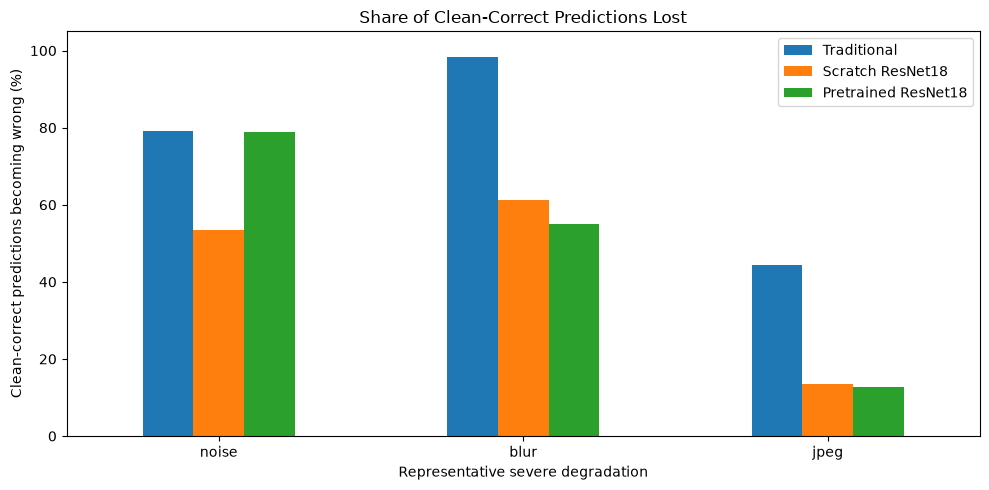

In [15]:
REPRESENTATIVE_CONDITIONS = [
    ("noise", "0.2"),
    ("blur", "7"),
    ("jpeg", "20"),
]


def load_prediction_file(path: Path):
    df = pd.read_csv(path)
    required = {"image_path", "true_idx", "pred_idx"}
    missing = required - set(df.columns)
    assert not missing, f"{path.name} is missing columns: {missing}"

    df = df.copy()
    df["path_key"] = df["image_path"].map(normalise_image_path)
    return df


transition_rows = []
merged_prediction_cache = {}

for model in MODELS:
    clean_df = load_prediction_file(
        CLEAN_DIR / f"{model}_predictions.csv"
    )[["path_key", "image_path", "true_idx", "pred_idx"]].rename(
        columns={"pred_idx": "clean_pred_idx"}
    )

    for degradation, severity in REPRESENTATIVE_CONDITIONS:
        degraded_path = (
            ROBUSTNESS_PREDICTIONS_DIR
            / f"{model}_{degradation}_{severity}_predictions.csv"
        )

        degraded_predictions = load_prediction_file(
            degraded_path
        )[["path_key", "true_idx", "pred_idx"]].rename(
            columns={
                "true_idx": "degraded_true_idx",
                "pred_idx": "degraded_pred_idx",
            }
        )

        merged = clean_df.merge(
            degraded_predictions,
            on="path_key",
            how="inner",
            validate="one_to_one",
        )

        assert len(merged) == 5000
        assert (
            merged["true_idx"] == merged["degraded_true_idx"]
        ).all()

        merged["clean_correct"] = (
            merged["clean_pred_idx"] == merged["true_idx"]
        )
        merged["degraded_correct"] = (
            merged["degraded_pred_idx"] == merged["true_idx"]
        )

        correct_to_correct = int(
            (merged["clean_correct"] & merged["degraded_correct"]).sum()
        )
        correct_to_wrong = int(
            (merged["clean_correct"] & ~merged["degraded_correct"]).sum()
        )
        wrong_to_correct = int(
            (~merged["clean_correct"] & merged["degraded_correct"]).sum()
        )
        wrong_to_wrong = int(
            (~merged["clean_correct"] & ~merged["degraded_correct"]).sum()
        )

        clean_correct_total = correct_to_correct + correct_to_wrong
        clean_wrong_total = wrong_to_correct + wrong_to_wrong

        transition_rows.append({
            "model": model,
            "degradation": degradation,
            "severity": severity,
            "clean_correct_total": clean_correct_total,
            "clean_wrong_total": clean_wrong_total,
            "correct_to_correct": correct_to_correct,
            "correct_to_wrong": correct_to_wrong,
            "wrong_to_correct": wrong_to_correct,
            "wrong_to_wrong": wrong_to_wrong,
            "correct_to_wrong_rate_pct": (
                correct_to_wrong / clean_correct_total * 100
                if clean_correct_total else np.nan
            ),
            "wrong_to_correct_rate_pct": (
                wrong_to_correct / clean_wrong_total * 100
                if clean_wrong_total else np.nan
            ),
        })

        merged_prediction_cache[
            (model, degradation, severity)
        ] = merged


failure_transitions = pd.DataFrame(transition_rows)
failure_transitions.to_csv(
    ROBUSTNESS_DIR / "failure_transition_summary.csv",
    index=False,
)

display(failure_transitions.round(2))

loss_rate_pivot = (
    failure_transitions
    .pivot(
        index="degradation",
        columns="model",
        values="correct_to_wrong_rate_pct",
    )
    .reindex(["noise", "blur", "jpeg"])
    [MODELS]
)

loss_rate_pivot.columns = [
    MODEL_LABELS[column]
    for column in loss_rate_pivot.columns
]

ax = loss_rate_pivot.plot(
    kind="bar",
    figsize=(10, 5),
)
ax.set_title("Share of Clean-Correct Predictions Lost")
ax.set_xlabel("Representative severe degradation")
ax.set_ylabel("Clean-correct predictions becoming wrong (%)")
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "A2_clean_correct_loss_rate.png",
    dpi=200,
)
plt.show()

## 12. Per-class degradation sensitivity

This calculates class-level clean accuracy, degraded accuracy and accuracy drop for the representative conditions.

Species names are read from `selected_classes.txt`, whose tab-separated fields are:

```text
class_idx    original_category_id    species_name
```

This is important because `idx_to_class.json` stores the original iNaturalist category ID, not the scientific species name.

In [16]:
selected_classes_path = (
    PROJECT_ROOT / "data" / "splits" / "selected_classes.txt"
)

idx_to_category_id = {}
idx_to_species_name = {}

if selected_classes_path.exists():
    with selected_classes_path.open(
        "r",
        encoding="utf-8",
    ) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split("\t", 2)
            if len(parts) != 3:
                raise ValueError(
                    "Unexpected selected_classes.txt format: "
                    f"{line}"
                )

            class_idx, category_id, species_name = parts
            class_idx = int(class_idx)

            idx_to_category_id[class_idx] = int(category_id)
            idx_to_species_name[class_idx] = species_name
else:
    idx_to_category_id = {
        index: index
        for index in range(500)
    }
    idx_to_species_name = {
        index: f"class_{index}"
        for index in range(500)
    }

assert len(idx_to_species_name) == 500, (
    "Expected 500 class-to-species mappings."
)

mapping_preview = pd.DataFrame([
    {
        "class_idx": class_idx,
        "category_id": idx_to_category_id[class_idx],
        "species_name": idx_to_species_name[class_idx],
    }
    for class_idx in range(10)
])

display(mapping_preview)

per_class_rows = []

for (
    model,
    degradation,
    severity,
), merged in merged_prediction_cache.items():

    class_summary = (
        merged.groupby("true_idx")
        .agg(
            clean_accuracy=("clean_correct", "mean"),
            degraded_accuracy=("degraded_correct", "mean"),
            num_images=("true_idx", "size"),
        )
        .reset_index()
    )

    class_summary["accuracy_drop"] = (
        class_summary["clean_accuracy"]
        - class_summary["degraded_accuracy"]
    )
    class_summary["model"] = model
    class_summary["degradation"] = degradation
    class_summary["severity"] = severity
    class_summary["category_id"] = (
        class_summary["true_idx"].map(idx_to_category_id)
    )
    class_summary["species_name"] = (
        class_summary["true_idx"].map(idx_to_species_name)
    )

    per_class_rows.append(class_summary)

per_class_drop_df = pd.concat(
    per_class_rows,
    ignore_index=True,
)

per_class_drop_df.to_csv(
    ROBUSTNESS_DIR / "per_class_degradation_drop.csv",
    index=False,
)

print(
    "Largest class-level drops for each "
    "representative condition:"
)

for degradation, severity in REPRESENTATIVE_CONDITIONS:
    subset = per_class_drop_df[
        (per_class_drop_df["degradation"] == degradation)
        & (per_class_drop_df["severity"] == severity)
    ]

    top_classes = (
        subset.groupby(
            ["true_idx", "category_id", "species_name"],
            as_index=False,
        )["accuracy_drop"]
        .mean()
        .sort_values(
            "accuracy_drop",
            ascending=False,
        )
        .head(10)
    )

    print(f"\n{degradation} {severity}")
    display(top_classes.round(3))

,class_idx,category_id,species_name
0,0,44,Trichonephila clavata
1,1,46,Trichonephila edulis
2,2,53,Badumna longinqua
3,3,70,Dolomedes triton
4,4,83,Lyssomanes viridis
5,5,89,Naphrys pulex
6,6,109,Aphonopelma chalcodes
7,7,110,Aphonopelma eutylenum
8,8,147,Leiobunum townsendi
9,9,170,Pollicipes polymerus


Largest class-level drops for each representative condition:

noise 0.2


,true_idx,category_id,species_name,accuracy_drop
61,61,1278,Opisthograptis luteolata,0.6330
283,283,5917,Nolina parryi,0.6000
63,63,1387,Oligoria maculata,0.5330
269,269,5635,Inonotus obliquus,0.5330
262,262,5567,Coprinopsis variegata,0.5330
231,231,4917,Imantodes cenchoa,0.5330
219,219,4766,Ornithorhynchus anatinus,0.5330
319,319,6714,Cirsium pitcheri,0.5330
306,306,6432,Stipa pennata,0.5000
103,103,2340,Agriocnemis femina,0.5000



blur 7


,true_idx,category_id,species_name,accuracy_drop
269,269,5635,Inonotus obliquus,0.6000
266,266,5580,Hypholoma lateritium,0.5670
311,311,6551,Aralia racemosa,0.5670
351,351,7394,Opuntia basilaris,0.5330
415,415,8453,Leonurus cardiaca,0.5330
308,308,6458,Hedychium gardnerianum,0.5330
319,319,6714,Cirsium pitcheri,0.5000
246,246,5201,Pisaster giganteus,0.5000
268,268,5613,Scleroderma citrinum,0.5000
350,350,7375,Escobaria vivipara,0.5000



jpeg 20


,true_idx,category_id,species_name,accuracy_drop
265,265,5576,Agrocybe praecox,0.2330
389,389,8062,Senna armata,0.2000
146,146,3135,Buteo swainsoni,0.2000
238,238,5066,Uta stansburiana,0.2000
373,373,7851,Lysimachia clethroides,0.1670
271,271,5684,Lentinus arcularius,0.1670
283,283,5917,Nolina parryi,0.1670
247,247,5227,Cyrtopleura costata,0.1670
72,72,1566,Agrotis munda,0.1670
297,297,6246,Carex hystericina,0.1670


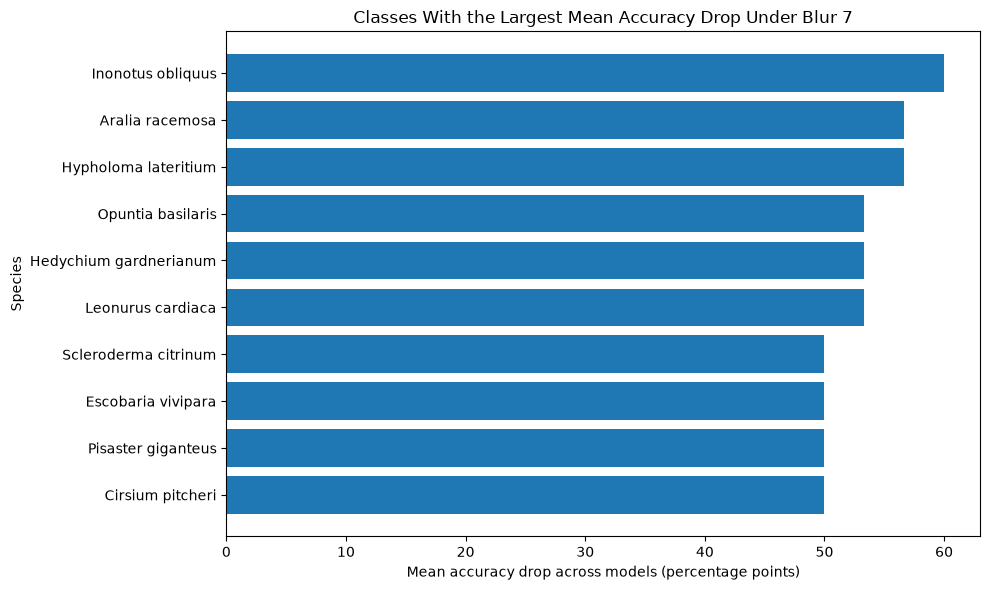

In [17]:
blur_class_drop = (
    per_class_drop_df[
        (per_class_drop_df["degradation"] == "blur")
        & (per_class_drop_df["severity"] == "7")
    ]
    .groupby(
        ["true_idx", "species_name"],
        as_index=False,
    )["accuracy_drop"]
    .mean()
    .sort_values(
        "accuracy_drop",
        ascending=False,
    )
    .head(10)
    .sort_values(
        "accuracy_drop",
        ascending=True,
    )
)

plt.figure(figsize=(10, 6))
plt.barh(
    blur_class_drop["species_name"],
    blur_class_drop["accuracy_drop"] * 100,
)
plt.title(
    "Classes With the Largest Mean "
    "Accuracy Drop Under Blur 7"
)
plt.xlabel(
    "Mean accuracy drop across models "
    "(percentage points)"
)
plt.ylabel("Species")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "A2_blur7_sensitive_classes.png",
    dpi=200,
)
plt.show()

## 13. Representative visual failure cases

For each model, one clean-correct image that becomes wrong under blur 7 is displayed. Blur is deterministic, so the visualised degradation is reproducible.

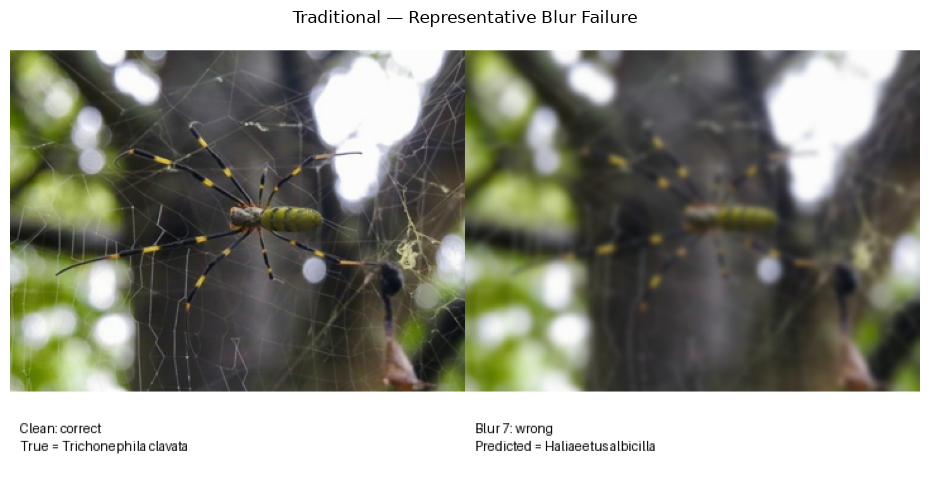

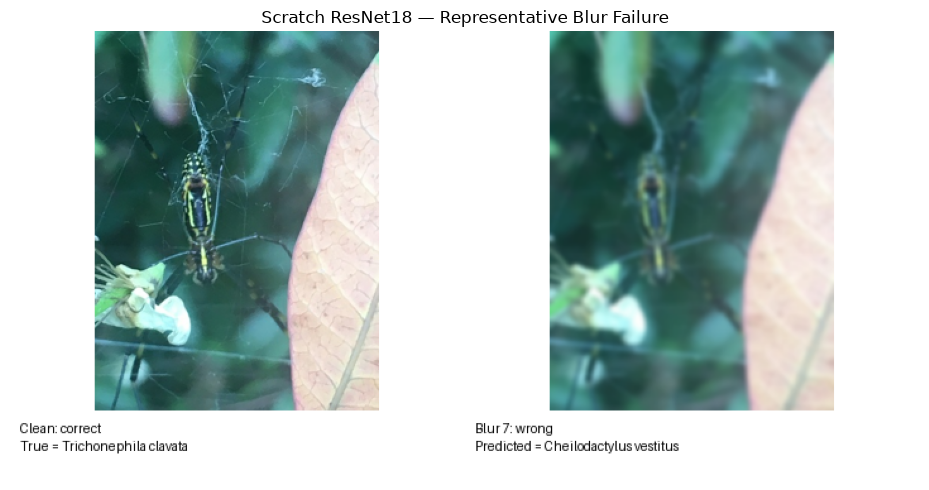

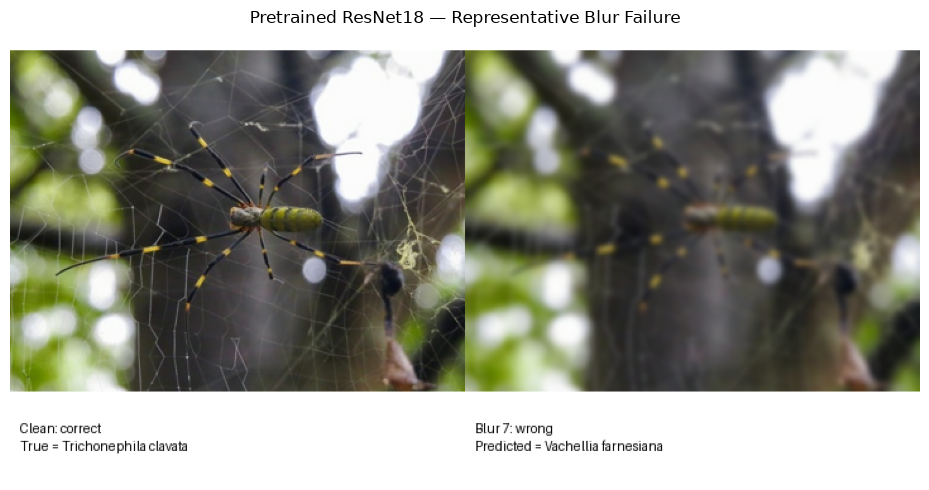

Visual failure examples generated: 3


In [18]:
def build_failure_pair(
    original,
    degraded,
    left_label,
    right_label,
    tile_size=(360, 300),
):
    left = make_labeled_tile(
        original,
        left_label,
        tile_size=tile_size,
        text_height=55,
    )
    right = make_labeled_tile(
        degraded,
        right_label,
        tile_size=tile_size,
        text_height=55,
    )

    output = Image.new(
        "RGB",
        (
            left.width + right.width,
            max(left.height, right.height),
        ),
        "white",
    )
    output.paste(left, (0, 0))
    output.paste(right, (left.width, 0))
    return output


visualised_models = 0

for model in MODELS:
    merged = merged_prediction_cache[
        (model, "blur", "7")
    ]

    candidates = merged[
        merged["clean_correct"]
        & ~merged["degraded_correct"]
    ].copy()

    if candidates.empty:
        print(
            f"No clean-correct to blur-wrong "
            f"case found for {model}."
        )
        continue

    row = candidates.iloc[0]
    image_path = resolve_image_path(
        row["image_path"]
    )

    if image_path is None:
        print(
            f"Raw image not found for {model}; "
            "skipping visual failure example."
        )
        continue

    original = Image.open(
        image_path
    ).convert("RGB")

    blurred = apply_degradation(
        original,
        "blur",
        7,
    )

    true_label = idx_to_species_name.get(
        int(row["true_idx"]),
        str(row["true_idx"]),
    )
    wrong_label = idx_to_species_name.get(
        int(row["degraded_pred_idx"]),
        str(row["degraded_pred_idx"]),
    )

    failure_pair = build_failure_pair(
        original,
        blurred,
        f"Clean: correct\nTrue = {true_label}",
        f"Blur 7: wrong\nPredicted = {wrong_label}",
    )

    output_path = (
        FIGURE_DIR
        / f"A2_failure_example_{model}_blur7.png"
    )
    failure_pair.save(output_path)

    plt.figure(figsize=(12, 5))
    plt.imshow(failure_pair)
    plt.axis("off")
    plt.title(
        f"{MODEL_LABELS[model]} — "
        "Representative Blur Failure"
    )
    plt.tight_layout()
    plt.show()

    visualised_models += 1

print(
    "Visual failure examples generated:",
    visualised_models,
)

## 14. Automatically generate key findings

These report-ready statements are generated from the actual result values.

In [19]:
finding_lines = []

clean_ranked = clean_summary.sort_values(
    "top1_accuracy",
    ascending=False,
)

finding_lines.append(
    "Clean performance ranking: "
    + " > ".join(
        f"{row['model_label']} "
        f"({row['top1_accuracy'] * 100:.2f}%)"
        for _, row in clean_ranked.iterrows()
    )
    + "."
)

average_severe_drop = (
    strongest_df.groupby("degradation")[
        "top1_absolute_drop"
    ]
    .mean()
    .sort_values(ascending=False)
)

most_damaging = average_severe_drop.index[0]

finding_lines.append(
    f"Across the three models, {most_damaging} causes "
    "the largest mean Top-1 drop at the strongest "
    f"severity ({average_severe_drop.iloc[0] * 100:.2f} "
    "percentage points)."
)

for model in MODELS:
    model_df = strongest_df[
        strongest_df["model"] == model
    ]
    worst = model_df.loc[
        model_df["top1_absolute_drop"].idxmax()
    ]

    finding_lines.append(
        f"{MODEL_LABELS[model]}'s largest "
        "strongest-severity drop is under "
        f"{worst['degradation']} {worst['severity']}: "
        f"{worst['top1_absolute_drop'] * 100:.2f} "
        "percentage points lost, with "
        f"{worst['top1_retention_pct']:.2f}% retained."
    )

improvements = degraded_df[
    degraded_df["top1_accuracy"]
    > degraded_df["clean_top1_accuracy"]
].copy()

if not improvements.empty:
    improvement_text = "; ".join(
        f"{MODEL_LABELS[row['model']]} on "
        f"{row['degradation']} {row['severity']}"
        for _, row in improvements.iterrows()
    )

    finding_lines.append(
        "Small score increases above the clean baseline "
        f"occur for {improvement_text}. These should be "
        "treated as evaluation variation rather than "
        "evidence that degradation reliably improves "
        "the model."
    )

largest_loss_rate = failure_transitions.loc[
    failure_transitions[
        "correct_to_wrong_rate_pct"
    ].idxmax()
]

finding_lines.append(
    "The largest proportional loss of clean-correct "
    f"predictions is {MODEL_LABELS[largest_loss_rate['model']]} "
    f"under {largest_loss_rate['degradation']} "
    f"{largest_loss_rate['severity']}: "
    f"{largest_loss_rate['correct_to_wrong_rate_pct']:.2f}% "
    "of its clean-correct predictions become wrong "
    f"({int(largest_loss_rate['correct_to_wrong'])} of "
    f"{int(largest_loss_rate['clean_correct_total'])} images)."
)

key_findings_text = "\n".join(
    f"- {line}"
    for line in finding_lines
)

print(key_findings_text)

key_findings_path = (
    ROBUSTNESS_DIR / "A2_key_findings.txt"
)
key_findings_path.write_text(
    key_findings_text,
    encoding="utf-8",
)

print("\nSaved:", key_findings_path)

- Clean performance ranking: Pretrained ResNet18 (68.24%) > Scratch ResNet18 (32.10%) > Traditional (10.74%).
- Across the three models, noise causes the largest mean Top-1 drop at the strongest severity (24.80 percentage points).
- Traditional's largest strongest-severity drop is under blur 7.0: 9.84 percentage points lost, with 8.38% retained.
- Scratch ResNet18's largest strongest-severity drop is under blur 7.0: 16.64 percentage points lost, with 48.16% retained.
- Pretrained ResNet18's largest strongest-severity drop is under noise 0.2: 52.76 percentage points lost, with 22.68% retained.
- Small score increases above the clean baseline occur for Scratch ResNet18 on brightness 0.8; Pretrained ResNet18 on brightness 0.8. These should be treated as evaluation variation rather than evidence that degradation reliably improves the model.
- The largest proportional loss of clean-correct predictions is Traditional under blur 7: 98.32% of its clean-correct predictions become wrong (528 of 

## 15. Output inventory

Main table outputs:

```text
results/clean/clean_model_comparison.csv
results/robustness/combined_robustness_results.csv
results/robustness/robustness_with_drop.csv
results/robustness/strongest_severity_comparison.csv
results/robustness/robustness_model_summary.csv
results/robustness/robustness_degradation_rankings.csv
results/robustness/failure_transition_summary.csv
results/robustness/per_class_degradation_drop.csv
results/robustness/A2_key_findings.txt
```

Generated figures are saved under `results/figures/`. They can be used in the report and video but excluded from the final 40 MB code ZIP if required.

In [20]:
expected_outputs = [
    CLEAN_DIR / "clean_model_comparison.csv",
    ROBUSTNESS_DIR / "combined_robustness_results.csv",
    ROBUSTNESS_DIR / "robustness_with_drop.csv",
    ROBUSTNESS_DIR / "strongest_severity_comparison.csv",
    ROBUSTNESS_DIR / "robustness_model_summary.csv",
    ROBUSTNESS_DIR / "robustness_degradation_rankings.csv",
    ROBUSTNESS_DIR / "failure_transition_summary.csv",
    ROBUSTNESS_DIR / "per_class_degradation_drop.csv",
    ROBUSTNESS_DIR / "A2_key_findings.txt",
    FIGURE_DIR / "A2_clean_model_comparison.png",
    FIGURE_DIR / "A2_strongest_severity_top1.png",
    FIGURE_DIR / "A2_mean_top1_drop_heatmap.png",
    FIGURE_DIR / "A2_strongest_top1_drop_heatmap.png",
    FIGURE_DIR / "A2_clean_correct_loss_rate.png",
    FIGURE_DIR / "A2_blur7_sensitive_classes.png",
]

output_inventory = pd.DataFrame([
    {
        "output": str(
            path.relative_to(PROJECT_ROOT)
        ).replace("\\", "/"),
        "exists": path.exists(),
        "size_kb": (
            round(path.stat().st_size / 1024, 1)
            if path.exists()
            else None
        ),
    }
    for path in expected_outputs
])

display(output_inventory)

,output,exists,size_kb
0,results/clean/clean_model_comparison.csv,True,0.4000
1,results/robustness/combined_robustness_results...,True,9.2000
2,results/robustness/robustness_with_drop.csv,True,14.8000
3,results/robustness/strongest_severity_comparis...,True,5.1000
4,results/robustness/robustness_model_summary.csv,True,0.6000
5,results/robustness/robustness_degradation_rank...,True,0.5000
6,results/robustness/failure_transition_summary.csv,True,0.9000
7,results/robustness/per_class_degradation_drop.csv,True,293.2000
8,results/robustness/A2_key_findings.txt,True,1.0000
9,results/figures/A2_clean_model_comparison.png,True,45.1000


## 16. Final summary

Member A's contribution includes the shared robustness protocol, input validation, 48-condition integration, clean comparison, performance-drop and retention analysis, robustness visualisation, prediction-transition analysis, class-level sensitivity analysis and report-ready findings.

After this notebook runs successfully, the remaining Member A tasks are to use these outputs in the written report, prepare the video explanation, update the repository documentation and help clean the final submission package.